# Experimento de Prueba — LightGBM Multivariado + Two-Stage
Objetivo: verificar que el pipeline completo funciona de extremo a extremo.

**Flujo:**
1. Setup
2. Cargar y preparar datos
3. Verificar features
4. Visualizar CV splits
5. Cross-validation — modelo único (baseline)
6. Loggear en MLflow
7. Evaluar en test set
8. Two-stage — baseline end-to-end
9. Análisis del umbral
10. Comparativa: two-stage vs modelo único


## 1. Setup

In [0]:
%pip install lightgbm --quiet
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('/Workspace/Repos/carlos.saquel@gmail.com/santiago-weather-forecast')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.data.ingestion import load_from_delta_table
from src.data.preprocessing import build_features, train_test_split, get_feature_names
from src.models.lightgbm_model import LightGBMPredictor
from src.models.two_stage_model import TwoStagePredictor
from src.evaluation.metrics import evaluate_model
from src.evaluation.cross_validation import TimeSeriesSplit, run_cv
from src.evaluation.two_stage_cv import run_cv_two_stage, evaluate_two_stage, find_best_threshold
from src.utils.mlflow_utils import setup_experiment, log_cv_run, log_test_evaluation
from src.utils.config import *

setup_experiment()
print('✅ Setup completo')


✅ MLflow experiment: /Users/carlos.saquel@gmail.com/santiago_weather_forecast
   ID: 237997826687442
✅ Setup completo


## 2. Cargar y preparar datos

In [0]:
# Cargar datos crudos desde Delta
df_raw = load_from_delta_table('weather_raw', spark)

# Pipeline completo de features
df = build_features(df_raw)

# Split train / test
df_train, df_test = train_test_split(df)

print(f'\n📋 Columnas totales: {df.shape[1]}')
print(f'   Features X:      {len(get_feature_names(df))}')
print(f'   Target:          {TARGET}')

✅ Cargados 3653 registros desde weather_raw
✅ Features construidas: 3653 filas x 176 columnas
   Features X: 164
   Target:     precip_t1
   NaN en target: 1 (último día, esperado)
📊 Train: 2896 días  (2016-02-01 → 2024-01-05)
📊 Test:  725 días   (2024-01-06 → 2025-12-30)

📋 Columnas totales: 176
   Features X:      164
   Target:          precip_t1


## 3. Verificar features

In [0]:
feature_names = get_feature_names(df)

print(f'Features ({len(feature_names)} total):')
for i, f in enumerate(feature_names):
    print(f'  {i+1:3d}. {f}')

print(f'\n🔍 NaN por columna en df_train:')
nan_counts = df_train[feature_names + [TARGET]].isna().sum()
nan_counts = nan_counts[nan_counts > 0]
if len(nan_counts) == 0:
    print('  ✅ Sin NaN')
else:
    print(nan_counts)

print(f'\n📊 Estadísticas del target ({TARGET}):')
print(df_train[TARGET].describe().round(3))

Features (164 total):
    1. pressure_msl_mean
    2. pressure_msl_min
    3. pressure_msl_max
    4. surface_pressure_mean
    5. relative_humidity_2m_mean
    6. relative_humidity_2m_max
    7. dew_point_2m_mean
    8. dew_point_2m_min
    9. vapour_pressure_deficit_mean
   10. vapour_pressure_deficit_min
   11. cloud_cover_mean
   12. cloud_cover_max
   13. cloud_cover_low_mean
   14. cloud_cover_low_max
   15. cloud_cover_mid_mean
   16. cloud_cover_high_mean
   17. wind_speed_10m_mean
   18. wind_speed_10m_max
   19. wind_direction_10m_mean
   20. wind_gusts_10m_max
   21. pressure_trend_24h
   22. pressure_trend_48h
   23. pressure_range
   24. wind_west_component
   25. wind_north_component
   26. rh_vpd_interaction
   27. precip_lag1
   28. precip_horas_lag1
   29. temp_max_lag1
   30. temp_min_lag1
   31. temp_mean_lag1
   32. viento_max_lag1
   33. rafagas_max_lag1
   34. viento_dir_lag1
   35. wind_speed_10m_mean_lag1
   36. wind_gusts_10m_max_lag1
   37. wind_west_component

## 4. Visualizar CV splits


📊 5 folds generados (sliding window):
  Fold 1: train=1095d (2016-02-01→2019-01-30)  test=365d  (2019-01-31→2020-01-30)
  Fold 2: train=1095d (2017-01-25→2020-01-24)  test=365d  (2020-01-25→2021-01-23)
  Fold 3: train=1095d (2018-01-19→2021-01-17)  test=365d  (2021-01-18→2022-01-17)
  Fold 4: train=1095d (2019-01-13→2022-01-11)  test=365d  (2022-01-12→2023-01-11)
  Fold 5: train=1095d (2020-01-07→2023-01-05)  test=365d  (2023-01-06→2024-01-05)


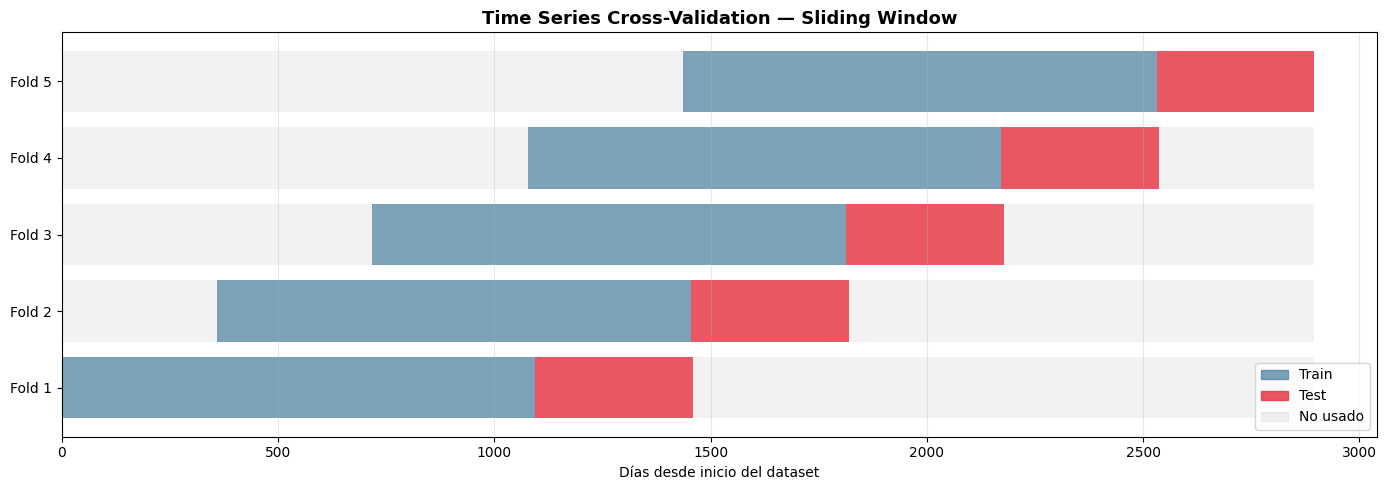

In [0]:
cv = TimeSeriesSplit(
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    min_train_size=MIN_TRAIN_SIZE,
    strategy='sliding'
)
cv.visualize(df_train)

## 5. Cross-validation

In [0]:
# Parámetros base — punto de partida limpio
# No tocar hasta confirmar que el pipeline funciona end-to-end
BASE_PARAMS = {
    'objective':              'tweedie',
    'tweedie_variance_power': 1.5,
    'n_estimators':           300,
    'learning_rate':          0.05,
    'max_depth':              6,
    'num_leaves':             31,
    'min_child_samples':      20,
    'subsample':              0.8,
    'colsample_bytree':       0.8,
    'reg_alpha':              0.1,
    'reg_lambda':             1.0,
}

print('📋 Parámetros base:')
for k, v in BASE_PARAMS.items():
    print(f'  {k:30s}: {v}')

📋 Parámetros base:
  objective                     : tweedie
  tweedie_variance_power        : 1.5
  n_estimators                  : 300
  learning_rate                 : 0.05
  max_depth                     : 6
  num_leaves                    : 31
  min_child_samples             : 20
  subsample                     : 0.8
  colsample_bytree              : 0.8
  reg_alpha                     : 0.1
  reg_lambda                    : 1.0


In [0]:
results_cv = run_cv(
    model_class=LightGBMPredictor,
    df=df_train,
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    min_train_size=MIN_TRAIN_SIZE,
    strategy='sliding',
    **BASE_PARAMS
)

display(results_cv)


📊 5 folds generados (sliding window):
  Fold 1: train=1095d (2016-02-01→2019-01-30)  test=365d  (2019-01-31→2020-01-30)
  Fold 2: train=1095d (2017-01-25→2020-01-24)  test=365d  (2020-01-25→2021-01-23)
  Fold 3: train=1095d (2018-01-19→2021-01-17)  test=365d  (2021-01-18→2022-01-17)
  Fold 4: train=1095d (2019-01-13→2022-01-11)  test=365d  (2022-01-12→2023-01-11)
  Fold 5: train=1095d (2020-01-07→2023-01-05)  test=365d  (2023-01-06→2024-01-05)

FOLD 1 / 5
✅ LightGBM entrenado — 164 features, 1095 muestras

Fold 1 - Resultados de Evaluación

📊 REGRESIÓN:
  MAE:  0.523 mm
  RMSE: 2.012 mm
  R²:   -0.088
  MAPE: 163.7%

🎯 CLASIFICACIÓN (lluvia sí/no):
  Accuracy:  90.1%
  Precision: 38.5%
  Recall:    15.2%
  F1-Score:  0.217

FOLD 2 / 5
✅ LightGBM entrenado — 164 features, 1095 muestras

Fold 2 - Resultados de Evaluación

📊 REGRESIÓN:
  MAE:  0.679 mm
  RMSE: 3.743 mm
  R²:   0.024
  MAPE: 101.0%

🎯 CLASIFICACIÓN (lluvia sí/no):
  Accuracy:  94.2%
  Precision: 75.0%
  Recall:    33.3%
 

mae,rmse,r2,mape,accuracy,precision,recall,f1_score,true_positives,false_positives,true_negatives,false_negatives,fold,train_size,test_size,train_start,train_end,test_start,test_end
0.5228387036323335,2.0116940631495215,-0.08758239860430006,163.66590842607116,0.9013698630136986,0.38461538461538464,0.15151515151515152,0.21739130434782608,5.0,8.0,324.0,28.0,1,1095.0,365.0,2016-02-01,2019-01-30,2019-01-31,2020-01-30
0.6788996431960828,3.743228367683331,0.02384793549954345,100.9935867378863,0.9424657534246575,0.75,0.3333333333333333,0.46153846153846156,9.0,3.0,335.0,18.0,2,1095.0,365.0,2017-01-25,2020-01-24,2020-01-25,2021-01-23
0.8093787611094603,4.040716989708565,-0.011636960510165384,93.7058771163836,0.9041095890410958,0.8333333333333334,0.1282051282051282,0.2222222222222222,5.0,1.0,325.0,34.0,3,1095.0,365.0,2018-01-19,2021-01-17,2021-01-18,2022-01-17
0.8193891041503039,3.5667753712676262,0.01935598319637344,100.67723897767576,0.915068493150685,0.6363636363636364,0.20588235294117646,0.3111111111111111,7.0,4.0,327.0,27.0,4,1095.0,365.0,2019-01-13,2022-01-11,2022-01-12,2023-01-11
1.3718633455526126,6.246634294785743,-0.02038894698912075,96.46505217053637,0.9123287671232877,0.8333333333333334,0.1388888888888889,0.2380952380952381,5.0,1.0,328.0,31.0,5,1095.0,365.0,2020-01-07,2023-01-05,2023-01-06,2024-01-05
0.8404739115281586,3.9218098173189575,-0.015280877481533861,111.10153268571064,0.9150684931506851,null,null,0.29007166746297186,null,null,null,null,promedio,null,null,null,null,null,null


## 6. Loggear en MLflow

In [0]:
# Con sliding: entrenar con los datos del último fold
cv_temp = TimeSeriesSplit(
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    min_train_size=MIN_TRAIN_SIZE,
    strategy='sliding'
)
last_train, _ = cv_temp.split(df_train)[-1]

model_final = LightGBMPredictor(**BASE_PARAMS)
model_final.fit(last_train)

print(f'📅 Modelo final entrenado con: '
      f'{last_train.index.min().date()} → {last_train.index.max().date()} '
      f'({len(last_train)} días)')

model_final.print_summary()

# Loggear en MLflow
run_id = log_cv_run(
    model=model_final,
    results_df=results_cv,
    model_params=BASE_PARAMS,
    run_name='LightGBM_baseline_v1',
    description='Baseline multivariado — todas las features, parámetros base',
    register_model=False,  # True solo cuando el modelo sea candidato a producción
)

print(f'\n🔗 Run ID: {run_id}')


📊 5 folds generados (sliding window):
  Fold 1: train=1095d (2016-02-01→2019-01-30)  test=365d  (2019-01-31→2020-01-30)
  Fold 2: train=1095d (2017-01-25→2020-01-24)  test=365d  (2020-01-25→2021-01-23)
  Fold 3: train=1095d (2018-01-19→2021-01-17)  test=365d  (2021-01-18→2022-01-17)
  Fold 4: train=1095d (2019-01-13→2022-01-11)  test=365d  (2022-01-12→2023-01-11)
  Fold 5: train=1095d (2020-01-07→2023-01-05)  test=365d  (2023-01-06→2024-01-05)
✅ LightGBM entrenado — 164 features, 1095 muestras
📅 Modelo final entrenado con: 2020-01-07 → 2023-01-05 (1095 días)

LightGBM — Resumen
  Objetivo:      tweedie
  N estimators:  300
  Learning rate: 0.05
  Max depth:     6
  Num leaves:    31
  N features:    164

  Top 10 features:
    wind_speed_10m_max                    2.6%  █
    dew_point_2m_mean_lag1                2.1%  █
    cloud_cover_low_max                   2.0%  
    cloud_cover_mid_mean                  1.9%  
    wind_west_component_rstd_14           1.8%  
    cloud_cover_mea

2026/03/16 04:32:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ Run loggeado: LightGBM_baseline_v1
   Run ID: 1d876b5a53a04bdabc544bc129039353

🔗 Run ID: 1d876b5a53a04bdabc544bc129039353


## 7. Evaluación en test set


LightGBM_baseline_v1 - Resultados de Evaluación

📊 REGRESIÓN:
  MAE:  1.099 mm
  RMSE: 5.320 mm
  R²:   -0.020
  MAPE: 91.5%

🎯 CLASIFICACIÓN (lluvia sí/no):
  Accuracy:  92.6%
  Precision: 66.7%
  Recall:    7.1%
  F1-Score:  0.129
✅ Métricas de test loggeadas en run 1d876b5a...


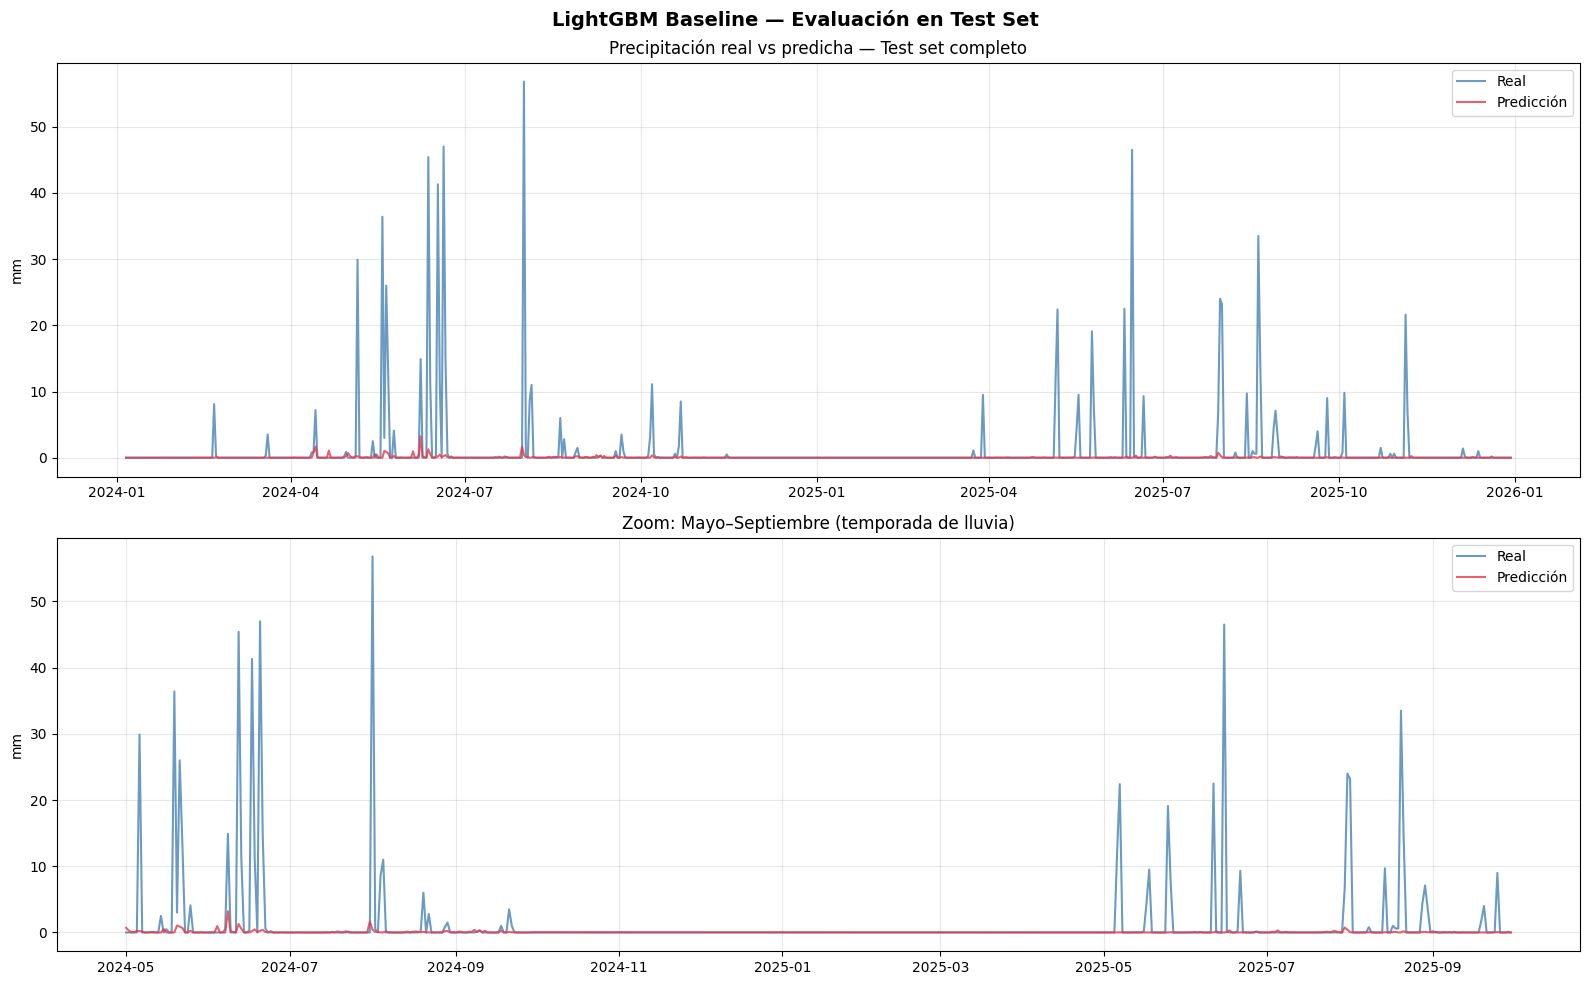

In [0]:
import matplotlib.pyplot as plt

# Predicciones en test
preds_test = model_final.predict(df_test)
y_test     = df_test[TARGET]

# Métricas
test_metrics = evaluate_model(y_test, preds_test, model_name='LightGBM_baseline_v1')

# Loggear métricas de test al run de CV
log_test_evaluation(
    run_id=run_id,
    test_metrics=test_metrics,
    description='Evaluación en test set holdout'
)

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('LightGBM Baseline — Evaluación en Test Set', fontsize=14, fontweight='bold')

# Panel 1: serie completa
axes[0].plot(y_test.index, y_test.values,
             label='Real', color='steelblue', alpha=0.8, linewidth=1.5)
axes[0].plot(preds_test.index, preds_test.values,
             label='Predicción', color='#e63946', alpha=0.8, linewidth=1.5)
axes[0].set_title('Precipitación real vs predicha — Test set completo')
axes[0].set_ylabel('mm')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: zoom en meses de invierno (donde hay más señal)
mask_invierno = (y_test.index.month >= 5) & (y_test.index.month <= 9)
axes[1].plot(y_test[mask_invierno].index, y_test[mask_invierno].values,
             label='Real', color='steelblue', alpha=0.8, linewidth=1.5)
axes[1].plot(preds_test[mask_invierno].index, preds_test[mask_invierno].values,
             label='Predicción', color='#e63946', alpha=0.8, linewidth=1.5)
axes[1].set_title('Zoom: Mayo–Septiembre (temporada de lluvia)')
axes[1].set_ylabel('mm')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

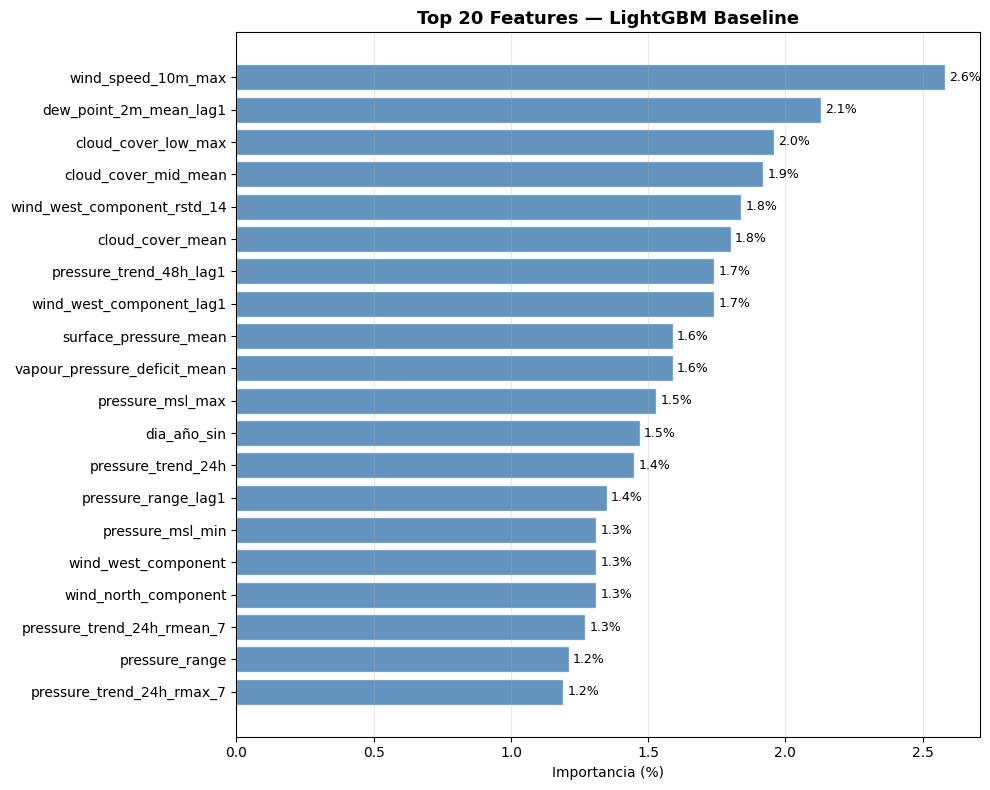

feature,importance,importance_pct
wind_speed_10m_max,132,2.58
dew_point_2m_mean_lag1,109,2.13
cloud_cover_low_max,100,1.96
cloud_cover_mid_mean,98,1.92
wind_west_component_rstd_14,94,1.84
cloud_cover_mean,92,1.8
pressure_trend_48h_lag1,89,1.74
wind_west_component_lag1,89,1.74
surface_pressure_mean,81,1.59
vapour_pressure_deficit_mean,81,1.59


In [0]:
importance = model_final.get_feature_importance(top_n=20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    importance['feature'][::-1],
    importance['importance_pct'][::-1],
    color='steelblue', edgecolor='white', alpha=0.85
)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('Importancia (%)')
ax.set_title('Top 20 Features — LightGBM Baseline', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

display(importance)

## 8. Grid Search — Clasificador

Busca la mejor configuración del clasificador (etapa 1).
Se evalúa AUC, F1, Precision y Recall por CV.
El umbral óptimo se busca en validación interna de cada fold (sin tocar test).

In [0]:
# Grid reducido para verificar el pipeline — en 04_grid_search va el grid completo
CLF_GRID = [
    {
        'name':              'clf_base',
        'n_estimators':      200,
        'learning_rate':     0.05,
        'max_depth':         6,
        'num_leaves':        31,
        'min_child_samples': 20,
        'subsample':         0.8,
        'colsample_bytree':  0.8,
    },
    {
        'name':              'clf_scale_pos',
        'n_estimators':      200,
        'learning_rate':     0.05,
        'max_depth':         6,
        'num_leaves':        31,
        'min_child_samples': 20,
        'is_unbalance':      False,        # reemplazar is_unbalance por scale_pos_weight
        'scale_pos_weight':  8.0,          # ~89/11 ratio de clases
        'subsample':         0.8,
        'colsample_bytree':  0.8,
    },
    {
        'name':              'clf_dart',
        'boosting_type':     'dart',
        'n_estimators':      200,
        'learning_rate':     0.1,
        'num_leaves':        40,
        'drop_rate':         0.15,
    },
]

print(f'📋 Configuraciones clf a probar: {len(CLF_GRID)}')
for c in CLF_GRID:
    print(f'  - {c["name"]}')


📋 Configuraciones clf a probar: 3
  - clf_base
  - clf_scale_pos
  - clf_dart


In [0]:
from src.evaluation.two_stage_cv import run_cv_clf_grid

results_clf_grid = run_cv_clf_grid(
    clf_grid=CLF_GRID,
    df=df_train,
    thresholds=CLF_THRESHOLDS,
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    min_train_size=MIN_TRAIN_SIZE,
    log_mlflow=True,
)

display(results_clf_grid[['name', 'best_threshold', 'avg_auc', 'avg_f1', 'std_f1',
                            'avg_precision', 'avg_recall']])



📊 5 folds generados (sliding window):
  Fold 1: train=1095d (2016-02-01→2019-01-30)  test=365d  (2019-01-31→2020-01-30)
  Fold 2: train=1095d (2017-01-25→2020-01-24)  test=365d  (2020-01-25→2021-01-23)
  Fold 3: train=1095d (2018-01-19→2021-01-17)  test=365d  (2021-01-18→2022-01-17)
  Fold 4: train=1095d (2019-01-13→2022-01-11)  test=365d  (2022-01-12→2023-01-11)
  Fold 5: train=1095d (2020-01-07→2023-01-05)  test=365d  (2023-01-06→2024-01-05)

GRID SEARCH — CLASIFICADOR (3 configs × 5 folds)

[1/3] clf_base
  Fold 1: thr=0.30  AUC=0.857  F1=0.459  Prec=0.373  Rec=0.595
  Fold 2: thr=0.20  AUC=0.884  F1=0.486  Prec=0.377  Rec=0.684
  Fold 3: thr=0.20  AUC=0.837  F1=0.454  Prec=0.458  Rec=0.450
  Fold 4: thr=0.20  AUC=0.803  F1=0.412  Prec=0.295  Rec=0.683
  Fold 5: thr=0.50  AUC=0.869  F1=0.463  Prec=0.432  Rec=0.500
  → AVG: AUC=0.850  F1=0.455  F1=0.479  Prec=0.387  Rec=0.582  thr=0.2

[2/3] clf_scale_pos
  Fold 1: thr=0.40  AUC=0.874  F1=0.455  Prec=0.390  Rec=0.548
  Fold 2: thr=0

name,best_threshold,avg_auc,avg_f1,std_f1,avg_precision,avg_recall
clf_dart,0.2,0.8507121420380889,0.4620086473790968,0.05091702476196443,0.40038454076603835,0.6038510911424904
clf_base,0.2,0.8499756684334951,0.4547315514750453,0.0269947598650901,0.38682561302572405,0.5824750901644354
clf_scale_pos,0.2,0.8462485482536877,0.4514874738643491,0.0390413011995343,0.375802709454355,0.5988819610000611


In [0]:
# Extraer mejor configuración clf
best_clf_row = results_clf_grid.iloc[0]
BEST_CLF_NAME      = best_clf_row['name']
BEST_CLF_THRESHOLD = float(best_clf_row['best_threshold'])

# Reconstruir params del clf ganador (sin columnas extra)
best_cfg = next(c for c in CLF_GRID if c['name'] == BEST_CLF_NAME)
BEST_CLF_PARAMS = {k: v for k, v in best_cfg.items() if k != 'name'}

print(f'🏆 Mejor clasificador: {BEST_CLF_NAME}')
print(f'   Umbral:    {BEST_CLF_THRESHOLD}')
print(f'   avg_F1:    {best_clf_row["avg_f1"]:.3f}')
print(f'   avg_AUC:   {best_clf_row["avg_auc"]:.3f}')
print(f'   avg_Prec:  {best_clf_row["avg_precision"]:.3f}')
print(f'   avg_Rec:   {best_clf_row["avg_recall"]:.3f}')


🏆 Mejor clasificador: clf_dart
   Umbral:    0.2
   avg_F1:    0.462
   avg_AUC:   0.851
   avg_Prec:  0.400
   avg_Rec:   0.604


## 9. Grid Search — Regresor

Fijando el mejor clasificador, busca la mejor configuración del regresor (etapa 2).
Se evalúa RMSE, R² y Recall de picos en días lluviosos reales.

In [0]:
# Grid reducido para verificar el pipeline
REG_GRID = [
    {
        'name':                   'reg_tweedie',
        'objective':              'tweedie',
        'tweedie_variance_power': 1.5,
        'n_estimators':           200,
        'learning_rate':          0.05,
        'max_depth':              6,
        'num_leaves':             31,
        'min_child_samples':      10,
        'subsample':              0.8,
        'colsample_bytree':       0.8,
        'reg_alpha':              0.1,
        'reg_lambda':             1.0,
    },
    {
        'name':              'reg_l1',
        'objective':         'regression_l1',
        'n_estimators':      200,
        'learning_rate':     0.05,
        'max_depth':         6,
        'num_leaves':        31,
        'min_child_samples': 10,
        'subsample':         0.8,
        'colsample_bytree':  0.8,
    },
    {
        'name':                   'reg_tweedie_log',   # igual que tweedie pero con log_target=True
        'objective':              'tweedie',
        'tweedie_variance_power': 1.5,
        'n_estimators':           200,
        'learning_rate':          0.05,
        'max_depth':              6,
        'num_leaves':             31,
        'min_child_samples':      10,
    },
]

print(f'📋 Configuraciones reg a probar: {len(REG_GRID)}')
for r in REG_GRID:
    print(f'  - {r["name"]}')
print(f'\n  Clf fijo:  {BEST_CLF_NAME}')
print(f'  Umbral:    {BEST_CLF_THRESHOLD}')


📋 Configuraciones reg a probar: 3
  - reg_tweedie
  - reg_l1
  - reg_tweedie_log

  Clf fijo:  clf_dart
  Umbral:    0.2


In [0]:
from src.evaluation.two_stage_cv import run_cv_reg_grid

results_reg_grid = run_cv_reg_grid(
    reg_grid=REG_GRID,
    best_clf_params=BEST_CLF_PARAMS,
    best_threshold=BEST_CLF_THRESHOLD,
    df=df_train,
    log_target=True,
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    min_train_size=MIN_TRAIN_SIZE,
    log_mlflow=True,
)

display(results_reg_grid[['name', 'avg_mae_rain', 'avg_rmse_rain', 'std_rmse_rain',
                            'avg_r2_rain', 'avg_recall_picos', 'avg_rmse']])



📊 5 folds generados (sliding window):
  Fold 1: train=1095d (2016-02-01→2019-01-30)  test=365d  (2019-01-31→2020-01-30)
  Fold 2: train=1095d (2017-01-25→2020-01-24)  test=365d  (2020-01-25→2021-01-23)
  Fold 3: train=1095d (2018-01-19→2021-01-17)  test=365d  (2021-01-18→2022-01-17)
  Fold 4: train=1095d (2019-01-13→2022-01-11)  test=365d  (2022-01-12→2023-01-11)
  Fold 5: train=1095d (2020-01-07→2023-01-05)  test=365d  (2023-01-06→2024-01-05)

GRID SEARCH — REGRESOR (3 configs × 5 folds)
  Clf fijo: best_clf  |  Umbral fijo: 0.2

[1/3] reg_tweedie
✅ Clasificador entrenado — 1095 muestras (183 lluviosas >0.5mm, 912 secas)
✅ Regresor entrenado   — 183 días lluviosos (log1p)
  Fold 1: RMSE_rain=5.22  R²_rain=-0.386  Recall_picos=—
✅ Clasificador entrenado — 1095 muestras (169 lluviosas >0.5mm, 926 secas)
✅ Regresor entrenado   — 169 días lluviosos (log1p)
  Fold 2: RMSE_rain=10.30  R²_rain=-0.050  Recall_picos=100%
✅ Clasificador entrenado — 1095 muestras (129 lluviosas >0.5mm, 966 seca

name,avg_mae_rain,avg_rmse_rain,std_rmse_rain,avg_r2_rain,avg_recall_picos,avg_rmse
reg_l1,6.280399611060392,10.78970016380417,4.905021782985781,-0.34743366138049836,0.7625,3.777806346059043
reg_tweedie,6.321709419534133,10.834339209294138,4.952846653671364,-0.3643325237277931,0.7625,3.785366459334967
reg_tweedie_log,6.315344877209459,10.862506223022931,4.897727467118999,-0.3826430363608263,0.7,3.8310141625173073


In [0]:
# Extraer mejor configuración reg
best_reg_row = results_reg_grid.iloc[0]
BEST_REG_NAME = best_reg_row['name']

best_reg_cfg  = next(r for r in REG_GRID if r['name'] == BEST_REG_NAME)
BEST_REG_PARAMS = {k: v for k, v in best_reg_cfg.items() if k != 'name'}

print(f'🏆 Mejor regresor: {BEST_REG_NAME}')
print(f'   avg_RMSE_rain:    {best_reg_row["avg_rmse_rain"]:.2f} mm')
print(f'   avg_R²_rain:      {best_reg_row["avg_r2_rain"]:.3f}')
print(f'   avg_Recall_picos: {best_reg_row["avg_recall_picos"]*100:.0f}%')


🏆 Mejor regresor: reg_l1
   avg_RMSE_rain:    10.79 mm
   avg_R²_rain:      -0.347
   avg_Recall_picos: 76%


## 10. Evaluación final — Two-Stage vs Modelo único

Reentrenar la combinación ganadora con `df_train` completo y evaluar en test set.
Comparar contra el baseline `regression_l1`.

In [0]:
# ── Modelo único baseline ─────────────────────────────────────────
BEST_SINGLE_PARAMS = {
    'objective':         'regression_l1',
    'n_estimators':      300,
    'learning_rate':     0.05,
    'max_depth':         6,
    'num_leaves':        31,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
}
single_model = LightGBMPredictor(**BEST_SINGLE_PARAMS)
single_model.fit(df_train)
preds_single = single_model.predict(df_test)

# ── Two-stage ganador ─────────────────────────────────────────────
ts_final = TwoStagePredictor(
    clf_params=BEST_CLF_PARAMS,
    reg_params=BEST_REG_PARAMS,
    threshold=BEST_CLF_THRESHOLD,
    log_target=True,
)
ts_final.fit(df_train)
preds_ts = ts_final.predict(df_test)
prob_ts  = ts_final.predict_proba(df_test)

y_test_vals = df_test[TARGET]
print(f'✅ Ambos modelos entrenados con {len(df_train)} días')
print(f'   Test: {len(df_test)} días ({y_test_vals.index.min().date()} → {y_test_vals.index.max().date()})')


✅ LightGBM entrenado — 164 features, 2896 muestras
✅ Clasificador entrenado — 2896 muestras (402 lluviosas >0.5mm, 2494 secas)
✅ Regresor entrenado   — 402 días lluviosos (log1p)
✅ Ambos modelos entrenados con 2896 días
   Test: 725 días (2024-01-06 → 2025-12-30)


In [0]:
from src.evaluation.metrics import evaluate_model
from src.evaluation.two_stage_cv import evaluate_two_stage

metrics_single = evaluate_model(y_test_vals, preds_single, model_name='regression_l1')
metrics_ts     = evaluate_two_stage(
    y_true=y_test_vals, y_pred=preds_ts, prob_llueve=prob_ts,
    threshold=BEST_CLF_THRESHOLD, label='TwoStage',
)

print('\n' + '='*65)
print('COMPARATIVA FINAL — Test Set')
print('='*65)
print(f'  {"Métrica":22s}  {"Modelo único (L1)":>18}  {"Two-Stage":>12}  {"Δ":>8}')
print(f'  {"-"*64}')

comparaciones = [
    ('rmse',         'RMSE (todos)',        True),
    ('r2',           'R² (todos)',          False),
    ('f1_score',     'F1 (clasificación)',  False),
    ('recall',       'Recall lluvia',       False),
    ('recall_picos', 'Recall picos >20mm',  False),
    ('mae_rain',     'MAE (días lluvia)',    True),
    ('rmse_rain',    'RMSE (días lluvia)',   True),
    ('r2_rain',      'R² (días lluvia)',     False),
    ('auc',          'AUC-ROC',             False),
]
for key, label, lower_better in comparaciones:
    v_s  = metrics_single.get(key, np.nan)
    v_ts = metrics_ts.get(key, np.nan)
    if pd.isna(v_s) or pd.isna(v_ts):
        print(f'  {label:22s}  {"—":>18}  {"—":>12}')
        continue
    delta = v_ts - v_s
    mejor = '✅' if (delta < 0 and lower_better) or (delta > 0 and not lower_better) else ('🔴' if delta != 0 else '⚪')
    print(f'  {label:22s}  {v_s:>18.3f}  {v_ts:>12.3f}  {mejor} {delta:+.3f}')



regression_l1 - Resultados de Evaluación

📊 REGRESIÓN:
  MAE:  1.105 mm
  RMSE: 4.983 mm
  R²:   0.105
  MAPE: 110.4%

🎯 CLASIFICACIÓN (lluvia sí/no):
  Accuracy:  90.9%
  Precision: 40.7%
  Recall:    39.3%
  F1-Score:  0.400

TwoStage — TwoStage — Evaluación

🎯 ETAPA 1 — Clasificador (umbral=0.2):
  AUC-ROC:   0.841
  F1:        0.402
  F1:        0.450  (recall x1)
  Precision: 28.2%
  Recall:    69.4%

📏 ETAPA 2 — Regresor (solo días lluviosos, n=72):
  MAE:   9.13 mm
  RMSE:  14.82 mm
  R²:    -0.290

⛈️  PICOS (>20mm, n=14):
  Recall: 78.6%

📊 COMBINADO (todos los días):
  MAE:   1.232 mm
  RMSE:  4.796 mm
  R²:    0.171

COMPARATIVA FINAL — Test Set
  Métrica                  Modelo único (L1)     Two-Stage         Δ
  ----------------------------------------------------------------
  RMSE (todos)                         4.983         4.796  ✅ -0.187
  R² (todos)                           0.105         0.171  ✅ +0.066
  F1 (clasificación)                       —             —
 

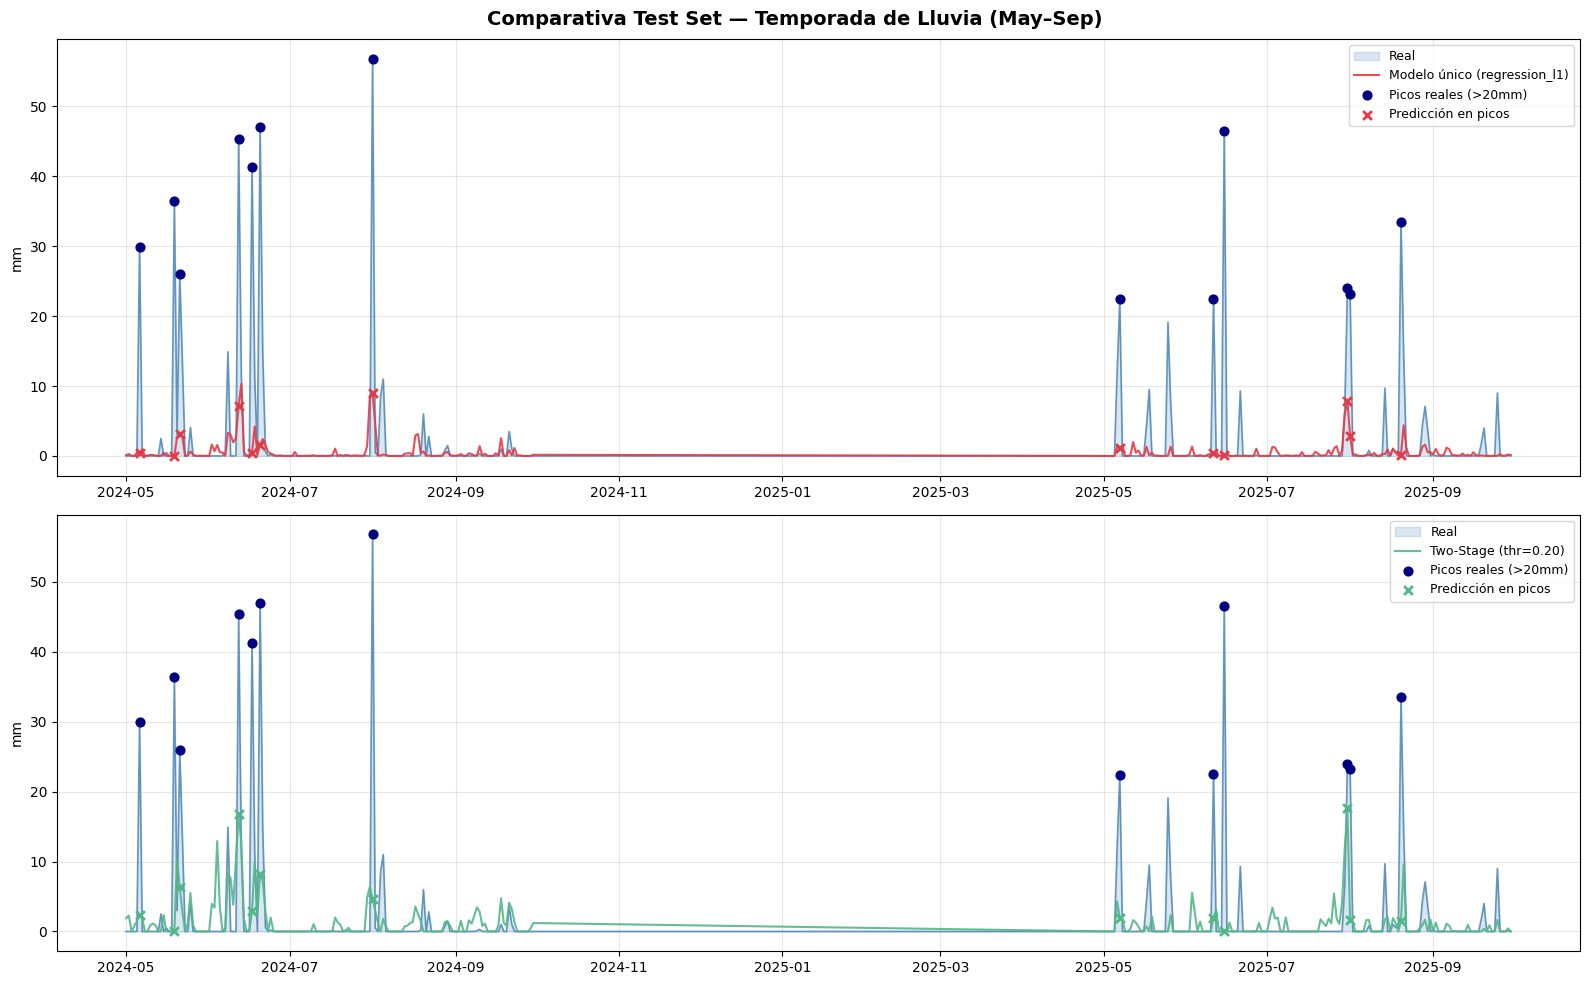

In [0]:
# Visualización en temporada de lluvia (Mayo–Septiembre)
mask_inv = (y_test_vals.index.month >= 5) & (y_test_vals.index.month <= 9)
y_inv    = y_test_vals[mask_inv]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Comparativa Test Set — Temporada de Lluvia (May–Sep)',
             fontsize=14, fontweight='bold')

for ax, (preds, label, color) in zip(axes, [
    (preds_single[mask_inv], 'Modelo único (regression_l1)', '#e63946'),
    (preds_ts[mask_inv],     f'Two-Stage (thr={BEST_CLF_THRESHOLD:.2f})', '#52b788'),
]):
    ax.fill_between(y_inv.index, 0, y_inv.values, alpha=0.2, color='steelblue', label='Real')
    ax.plot(y_inv.index, y_inv.values, color='steelblue', linewidth=1.2, alpha=0.8)
    ax.plot(preds.index, preds.values, color=color, linewidth=1.5, alpha=0.9, label=label)
    mask_p = y_inv > 20
    ax.scatter(y_inv.index[mask_p], y_inv.values[mask_p],
               color='navy', s=40, zorder=5, label='Picos reales (>20mm)')
    ax.scatter(preds.index[mask_p], preds.values[mask_p],
               color=color, s=40, marker='x', zorder=5, linewidth=2,
               label='Predicción en picos')
    ax.set_ylabel('mm')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


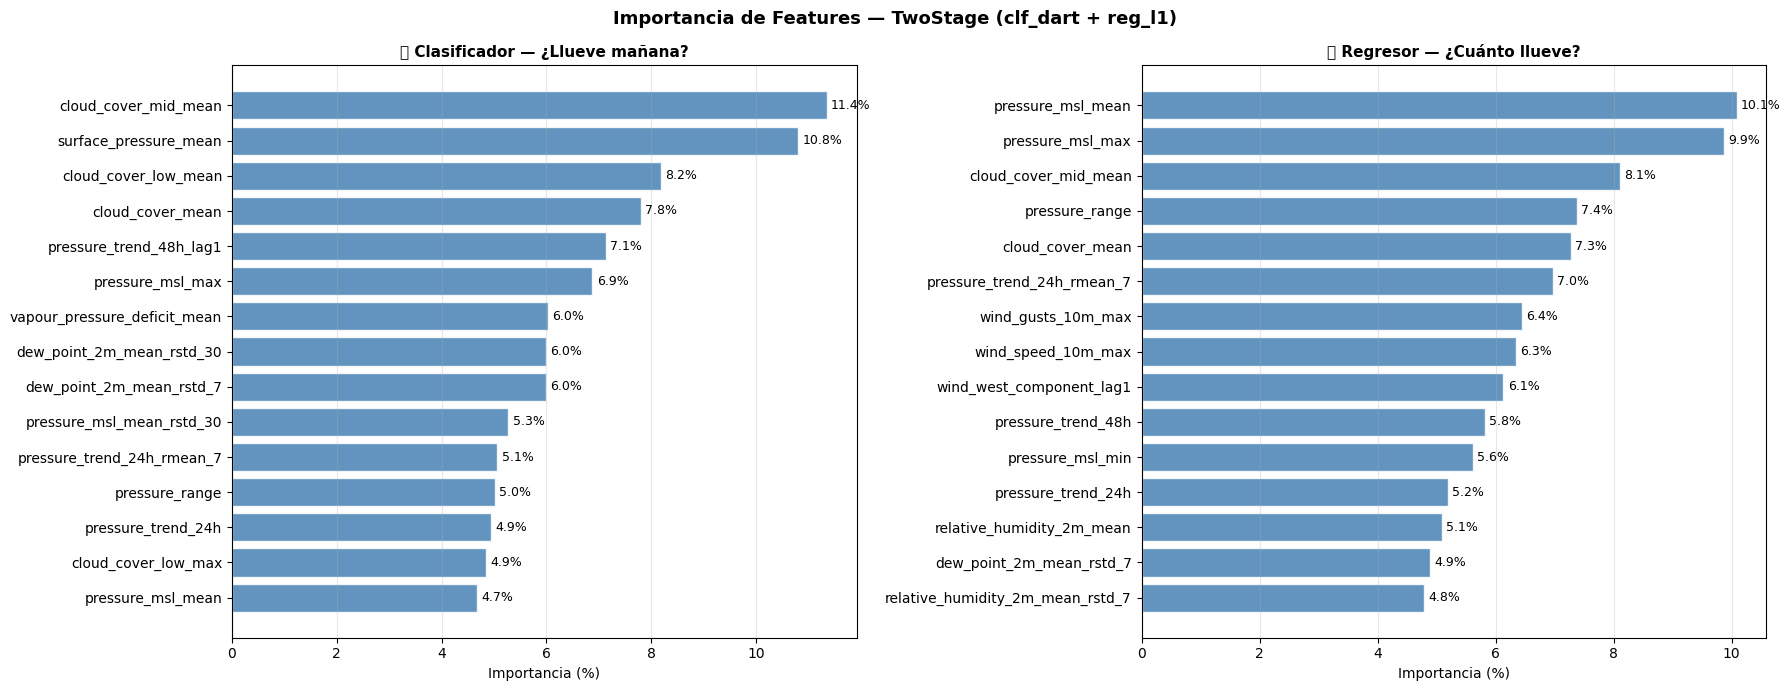


💡 Si clf y reg priorizan features distintas → señales complementarias correctamente capturadas.


In [0]:
# Importancia de features — clf vs reg
imp = ts_final.get_feature_importance(top_n=15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Importancia de Features — TwoStage ({BEST_CLF_NAME} + {BEST_REG_NAME})',
             fontsize=13, fontweight='bold')

for ax, (stage, title) in zip(axes, [
    ('clf', '🎯 Clasificador — ¿Llueve mañana?'),
    ('reg', '📏 Regresor — ¿Cuánto llueve?'),
]):
    df_imp = imp[stage]
    bars = ax.barh(df_imp['feature'][::-1], df_imp['importance_pct'][::-1],
                   color='steelblue', edgecolor='white', alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_xlabel('Importancia (%)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('\n💡 Si clf y reg priorizan features distintas → señales complementarias correctamente capturadas.')
